# Credit Card Fraud Detection

- **Problem Type**: Binary Classification
- **Evaluation Metric**: ROC-AUC, Precision, Recall, F1-Score
- **Class Distribution**: Highly Imbalanced (Fraud: ~0.17%, Legitimate: ~99.83%)
- **Models to test**:
  - Machine Learning
    - Logistic Regression (Base Model)
    - Decision Tree Classifier
    - Random Forest Classifier
    - Support Vector Classifier
    - K-Nearest Neighbors Classifier
  - Boosting
    - XGBoost Classifier
    - LightGBM Classifier
  - Deep Learning
    - Artificial Neural Network

## Loading Libraries

In [2]:
import os
os.environ["KERAS_BACKEND"] = "torch"

import datetime
import time

import math
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.model_selection import train_test_split, RandomizedSearchCV, KFold, StratifiedKFold
from sklearn.metrics import *
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

import keras
from keras.models import Sequential
from keras.layers import Dense, Dropout, BatchNormalization
from keras import optimizers
from keras.callbacks import EarlyStopping, ReduceLROnPlateau

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

import warnings
warnings.filterwarnings("ignore")

## Loading Data

In [3]:
df_og = pd.read_csv("creditcard.csv")
df_og.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## EDA (Exploratory Data Analysis)

### Basic information of data

In [4]:
print(f"Dataset Shape: {df_og.shape}")
print(f"\nColumn Names and Types:")
print(df_og.dtypes)
print(f"\nMissing Values:")
print(df_og.isnull().sum())
print(f"\nBasic Statistics:")
df_og.describe()

Dataset Shape: (284807, 31)

Column Names and Types:
Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object

Missing Values:
Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


### Target Variable Analysis - Class Distribution

Class Distribution:
Class
0    284315
1       492
Name: count, dtype: int64

Class Percentages:
Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64


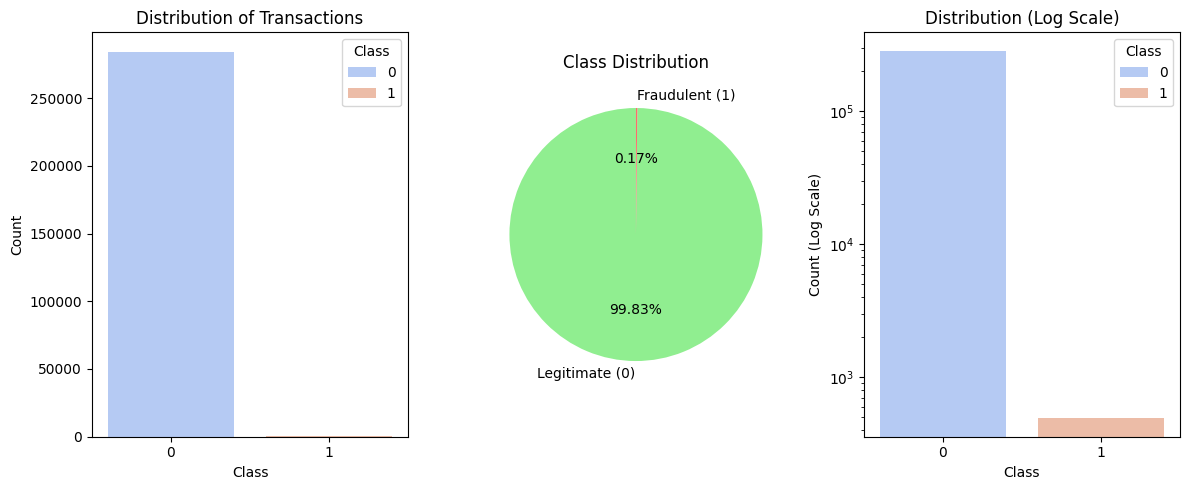


⚠️ SEVERE CLASS IMBALANCE DETECTED!
Fraud Rate: 0.173%
Imbalance Ratio: 1:578


In [5]:
# Class distribution
print("Class Distribution:")
print(df_og['Class'].value_counts())
print(f"\nClass Percentages:")
print(df_og['Class'].value_counts(normalize=True) * 100)

# Visualization
plt.figure(figsize=(12, 5))

# Plot 1: Count plot
plt.subplot(1, 3, 1)
sns.countplot(data=df_og, x='Class', hue='Class', palette='coolwarm')
plt.title('Distribution of Transactions')
plt.ylabel('Count')

# Plot 2: Pie chart
plt.subplot(1, 3, 2)
labels = ['Legitimate (0)', 'Fraudulent (1)']
sizes = df_og['Class'].value_counts().values
colors = ['#90EE90', '#FF6B6B']
plt.pie(sizes, labels=labels, autopct='%1.2f%%', colors=colors, startangle=90)
plt.title('Class Distribution')

# Plot 3: Log scale
plt.subplot(1, 3, 3)
sns.countplot(data=df_og, x='Class', hue='Class', palette='coolwarm')
plt.yscale('log')
plt.title('Distribution (Log Scale)')
plt.ylabel('Count (Log Scale)')

plt.tight_layout()
plt.show()

print("\n⚠️ SEVERE CLASS IMBALANCE DETECTED!")
print(f"Fraud Rate: {(df_og['Class'].sum() / len(df_og)) * 100:.3f}%")
print(f"Imbalance Ratio: 1:{int(len(df_og) / df_og['Class'].sum())}")

### Univariate Analysis - Amount and Time Features

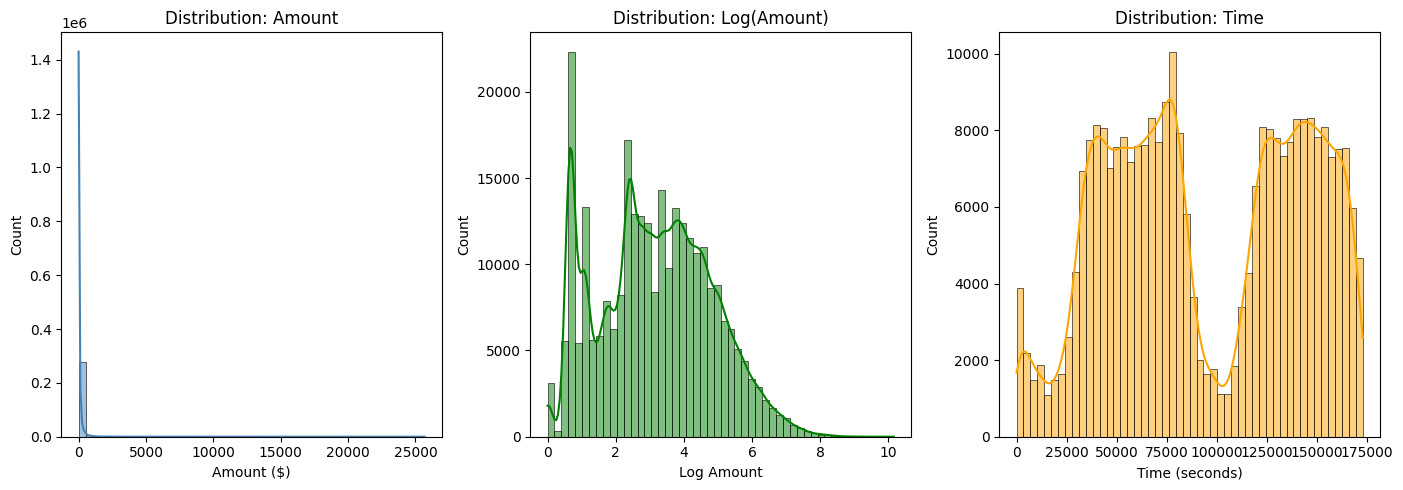

Amount Statistics:
count    284807.000000
mean         88.349619
std         250.120109
min           0.000000
25%           5.600000
50%          22.000000
75%          77.165000
max       25691.160000
Name: Amount, dtype: float64

Time Statistics:
count    284807.000000
mean      94813.859575
std       47488.145955
min           0.000000
25%       54201.500000
50%       84692.000000
75%      139320.500000
max      172792.000000
Name: Time, dtype: float64


In [6]:
plt.figure(figsize=(14, 5))

# Amount distribution
plt.subplot(1, 3, 1)
sns.histplot(df_og['Amount'], kde=True, bins=50, color='steelblue')
plt.title('Distribution: Amount')
plt.xlabel('Amount ($)')

# Amount - Log scale
plt.subplot(1, 3, 2)
sns.histplot(np.log1p(df_og['Amount']), kde=True, bins=50, color='green')
plt.title('Distribution: Log(Amount)')
plt.xlabel('Log Amount')

# Time distribution
plt.subplot(1, 3, 3)
sns.histplot(df_og['Time'], kde=True, bins=50, color='orange')
plt.title('Distribution: Time')
plt.xlabel('Time (seconds)')

plt.tight_layout()
plt.show()

print(f"Amount Statistics:")
print(df_og['Amount'].describe())
print(f"\nTime Statistics:")
print(df_og['Time'].describe())

### Bivariate Analysis - Features vs Target

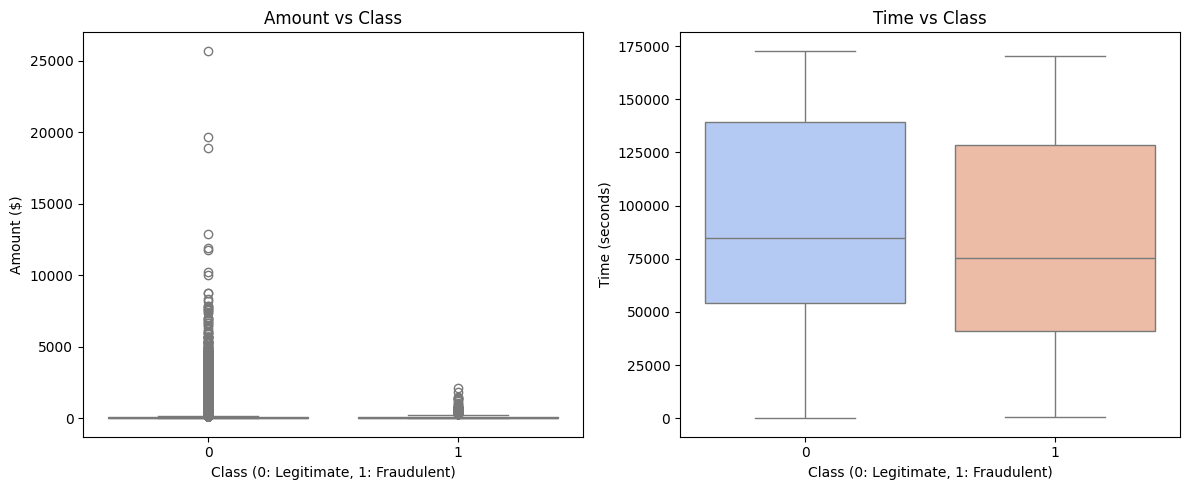


Amount Statistics by Class:
          count        mean         std  min   25%    50%     75%       max
Class                                                                      
0      284315.0   88.291022  250.105092  0.0  5.65  22.00   77.05  25691.16
1         492.0  122.211321  256.683288  0.0  1.00   9.25  105.89   2125.87


In [7]:
plt.figure(figsize=(12, 5))

# Amount vs Class
plt.subplot(1, 2, 1)
sns.boxplot(data=df_og, x='Class', y='Amount', palette='coolwarm')
plt.title('Amount vs Class')
plt.ylabel('Amount ($)')
plt.xlabel('Class (0: Legitimate, 1: Fraudulent)')

# Time vs Class
plt.subplot(1, 2, 2)
sns.boxplot(data=df_og, x='Class', y='Time', palette='coolwarm')
plt.title('Time vs Class')
plt.ylabel('Time (seconds)')
plt.xlabel('Class (0: Legitimate, 1: Fraudulent)')

plt.tight_layout()
plt.show()

# Statistics by class
print("\nAmount Statistics by Class:")
print(df_og.groupby('Class')['Amount'].describe())

### Multivariate Analysis - Correlation


Top 15 Features Correlated with Fraud:
Class     1.000000
V11       0.154876
V4        0.133447
V2        0.091289
V21       0.040413
V19       0.034783
V20       0.020090
V8        0.019875
V27       0.017580
V28       0.009536
Amount    0.005632
V26       0.004455
V25       0.003308
V22       0.000805
V23      -0.002685
Name: Class, dtype: float64


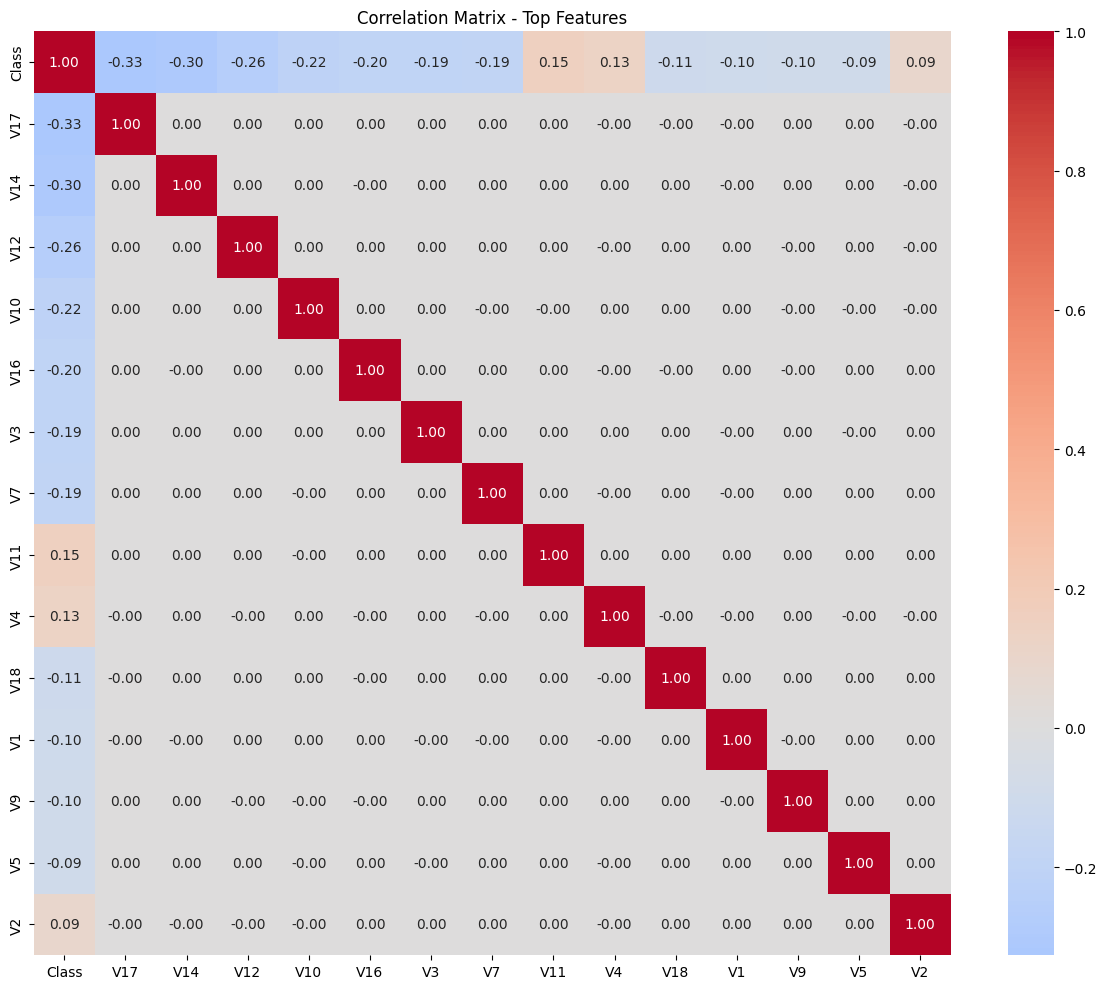

In [8]:
# Correlation with target
correlation_with_target = df_og.corr()['Class'].sort_values(ascending=False)
print("\nTop 15 Features Correlated with Fraud:")
print(correlation_with_target.head(15))

# Correlation heatmap (select top features)
top_features = correlation_with_target.abs().sort_values(ascending=False).index[:15]
plt.figure(figsize=(12, 10))
sns.heatmap(df_og[top_features].corr(), annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Matrix - Top Features')
plt.tight_layout()
plt.show()

## Preprocessing

### Make a copy of dataframe

In [9]:
df = df_og.copy(deep=True)

### Feature Engineering

In [10]:
# Log transform Amount (due to skewness)
df['Amount_log'] = np.log1p(df['Amount'])

# Create time-based features
df['Time_hour'] = (df['Time'] // 3600) % 24  # Extract hour of day
df['Time_sin'] = np.sin(2 * np.pi * df['Time'] / (24 * 3600))  # Cyclical encoding
df['Time_cos'] = np.cos(2 * np.pi * df['Time'] / (24 * 3600))

# Drop original Amount and Time (we'll use engineered versions)
df = df.drop(['Amount', 'Time'], axis=1)

print("Engineered features:")
print(df.head())
print(f"\nNew shape: {df.shape}")

Engineered features:
         V1        V2        V3        V4        V5        V6        V7  \
0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9       V10  ...       V24       V25       V26       V27  \
0  0.098698  0.363787  0.090794  ...  0.066928  0.128539 -0.189115  0.133558   
1  0.085102 -0.255425 -0.166974  ... -0.339846  0.167170  0.125895 -0.008983   
2  0.247676 -1.514654  0.207643  ... -0.689281 -0.327642 -0.139097 -0.055353   
3  0.377436 -1.387024 -0.054952  ... -1.175575  0.647376 -0.221929  0.062723   
4 -0.270533  0.817739  0.753074  ...  0.141267 -0.206010  0.502292  0.219422   

        V28  Class  Amount_log  Time_hour  Time

### Separate features and target

In [11]:
# Identify numerical features
target = "Class"

X = df.drop(target, axis=1)
y = df[target]

print(f"X Shape: {X.shape}")
print(f"y Shape: {y.shape}")
print(f"\nFeatures:")
print(X.columns.tolist())

X Shape: (284807, 32)
y Shape: (284807,)

Features:
['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount_log', 'Time_hour', 'Time_sin', 'Time_cos']


## Data Splitting & Handling Class Imbalance

In [12]:
# Stratified split to maintain class distribution
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training Set:")
print(f"  X_train Shape: {X_train.shape}")
print(f"  y_train Shape: {y_train.shape}")
print(f"  Fraud Rate: {y_train.sum() / len(y_train) * 100:.3f}%")

print(f"\nTest Set:")
print(f"  X_test Shape: {X_test.shape}")
print(f"  y_test Shape: {y_test.shape}")
print(f"  Fraud Rate: {y_test.sum() / len(y_test) * 100:.3f}%")

Training Set:
  X_train Shape: (227845, 32)
  y_train Shape: (227845,)
  Fraud Rate: 0.173%

Test Set:
  X_test Shape: (56962, 32)
  y_test Shape: (56962,)
  Fraud Rate: 0.172%


## Preprocessing Pipelines

In [13]:
# Define scalers for different model types

# 1. Standard Scaler for Linear/Distance models
linear_scaler = StandardScaler()

# 2. RobustScaler for outlier-resistant scaling
robust_scaler = RobustScaler()

# 3. MinMax Scaler for neural networks
nn_scaler = MinMaxScaler()

# Fit scalers on training data
X_train_linear = linear_scaler.fit_transform(X_train)
X_test_linear = linear_scaler.transform(X_test)

X_train_robust = robust_scaler.fit_transform(X_train)
X_test_robust = robust_scaler.transform(X_test)

X_train_nn = nn_scaler.fit_transform(X_train)
X_test_nn = nn_scaler.transform(X_test)

print("Preprocessing Complete!")
print(f"X_train_linear shape: {X_train_linear.shape}")
print(f"X_train_robust shape: {X_train_robust.shape}")
print(f"X_train_nn shape: {X_train_nn.shape}")

Preprocessing Complete!
X_train_linear shape: (227845, 32)
X_train_robust shape: (227845, 32)
X_train_nn shape: (227845, 32)


In [14]:
## Apply SMOTE for Training Data (Class Imbalance Handling)

In [32]:
# Limit training data to 30,000 records using stratified sampling
from sklearn.model_selection import train_test_split

sample_size = 30000

if len(X_train) > sample_size:
    X_train_sample, _, y_train_sample, _ = train_test_split(
        X_train, y_train, train_size=sample_size, random_state=42, stratify=y_train
    )
    
    # Apply same sampling to scaled versions
    X_train_linear_sample = linear_scaler.transform(X_train_sample)
    X_train_nn_sample = nn_scaler.transform(X_train_sample)
else:
    X_train_sample = X_train
    y_train_sample = y_train
    X_train_linear_sample = X_train_linear
    X_train_nn_sample = X_train_nn

print(f"Original training set size: {len(X_train)}")
print(f"Sampled training set size: {len(X_train_sample)}")

# Apply SMOTE only to training data
smote = SMOTE(random_state=42, k_neighbors=5)

# For linear models
X_train_linear_smote, y_train_smote = smote.fit_resample(X_train_linear_sample, y_train_sample)

# For tree models (use non-scaled data)
X_train_smote, y_train_smote = smote.fit_resample(X_train_sample.values, y_train_sample)

# For NN models
X_train_nn_smote, y_train_nn_smote = smote.fit_resample(X_train_nn_sample, y_train_sample)

print("\nSMOTE Applied!")
print(f"\nBefore SMOTE:")
print(f"  Total samples: {len(y_train_sample)}")
print(f"  Fraud: {y_train_sample.sum()} ({y_train_sample.sum()/len(y_train_sample)*100:.2f}%)")
print(f"  Legitimate: {len(y_train_sample) - y_train_sample.sum()} ({(len(y_train_sample) - y_train_sample.sum())/len(y_train_sample)*100:.2f}%)")

print(f"\nAfter SMOTE:")
print(f"  Total samples: {len(y_train_smote)}")
print(f"  Fraud: {y_train_smote.sum()} ({y_train_smote.sum()/len(y_train_smote)*100:.2f}%)")
print(f"  Legitimate: {len(y_train_smote) - y_train_smote.sum()} ({(len(y_train_smote) - y_train_smote.sum())/len(y_train_smote)*100:.2f}%)")

Original training set size: 227845
Sampled training set size: 30000

SMOTE Applied!

Before SMOTE:
  Total samples: 30000
  Fraud: 52 (0.17%)
  Legitimate: 29948 (99.83%)

After SMOTE:
  Total samples: 59896
  Fraud: 29948 (50.00%)
  Legitimate: 29948 (50.00%)


## Feature Selection & Analysis


Top 15 Features by Mutual Information:
      Feature  MI Score
13        V14  0.008135
16        V17  0.008099
11        V12  0.007534
9         V10  0.007518
10        V11  0.006685
15        V16  0.005930
3          V4  0.005073
2          V3  0.004939
8          V9  0.004318
17        V18  0.004151
6          V7  0.003884
1          V2  0.003200
29  Time_hour  0.003079
26        V27  0.002399
20        V21  0.002364


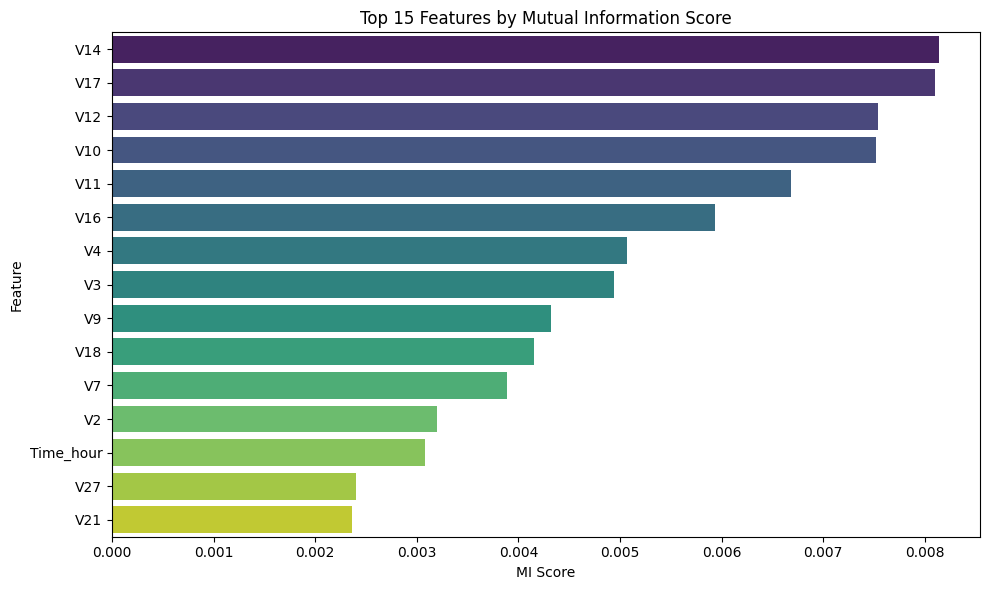

In [31]:
from sklearn.feature_selection import mutual_info_classif

# Calculate mutual information scores
mi_scores = mutual_info_classif(X_train, y_train, random_state=42)

mi_results = pd.DataFrame(
    {"Feature": X_train.columns, "MI Score": mi_scores}
).sort_values(by="MI Score", ascending=False)

print("\nTop 15 Features by Mutual Information:")
print(mi_results.head(15))

# Visualize feature importance
plt.figure(figsize=(10, 6))
sns.barplot(data=mi_results.head(15), x='MI Score', y='Feature', palette='viridis')
plt.title('Top 15 Features by Mutual Information Score')
plt.xlabel('MI Score')
plt.tight_layout()
plt.show()

## Machine Learning Models

In [ ]:
# Define ML models for classification
ml_models = {
    "Logistic Regression": LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced'),
    "Decision Tree": DecisionTreeClassifier(random_state=42, class_weight='balanced'),
    "Random Forest": RandomForestClassifier(random_state=42, class_weight='balanced', n_jobs=-1),
    "XGBoost": XGBClassifier(random_state=42, eval_metric='logloss', use_label_encoder=False),
}

print(f"Models defined: {list(ml_models.keys())}")

Models defined: ['Logistic Regression', 'Decision Tree', 'Random Forest', 'KNN', 'XGBoost']


## Model Training & Evaluation

In [33]:
results_list = []

for name, model in ml_models.items():
    print(f"Training {name}...")
    
    # Use appropriate data based on model type
    if name in ["Logistic Regression"]:
        X_train_use = X_train_linear_smote
        X_test_use = X_test_linear
    else:
        X_train_use = X_train_smote
        X_test_use = X_test.values
    
    # Train the model
    model.fit(X_train_use, y_train_smote)
    
    # Predictions
    y_pred = model.predict(X_test_use)
    y_pred_proba = model.predict_proba(X_test_use)[:, 1]
    
    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    roc_auc = roc_auc_score(y_test, y_pred_proba)
    
    results_list.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1,
        "ROC-AUC": roc_auc
    })
    
    print(f"  ✓ {name} trained")

ML_Results = pd.DataFrame(results_list).sort_values(by="ROC-AUC", ascending=False)

print("\n" + "="*80)
print("ML MODELS PERFORMANCE")
print("="*80)
display(ML_Results)

Training Logistic Regression...
  ✓ Logistic Regression trained
Training Decision Tree...
  ✓ Decision Tree trained
Training Random Forest...
  ✓ Random Forest trained
Training KNN...
  ✓ KNN trained
Training XGBoost...
  ✓ XGBoost trained

ML MODELS PERFORMANCE


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
4,XGBoost,0.999017,0.675000,0.826531,0.743119,0.968642
0,Logistic Regression,0.994997,0.236620,0.857143,0.370861,0.957747
2,Random Forest,0.999386,0.846154,0.785714,0.814815,0.956091
3,KNN,0.998385,0.519231,0.826531,0.637795,0.923031
1,Decision Tree,0.998086,0.462585,0.693878,0.555102,0.846244


### Conclusion:

- **Random Forest** and **XGBoost** show the best ROC-AUC scores, making them strong candidates for hyperparameter tuning
- **Recall is critical** for fraud detection (we want to catch as many frauds as possible)

## Hyperparameter Tuning

In [19]:
### Random Forest Hyperparameter Tuning

In [34]:
print("Starting Random Forest Hyperparameter Tuning...\n")

param_dist_rf = {
    "n_estimators": [50, 100],
    "max_depth": [10, 15],
    "min_samples_split": [5, 10],
    "min_samples_leaf": [2, 4],
    "max_features": ["sqrt"],
}

rf_base = RandomForestClassifier(
    random_state=42,
    class_weight='balanced',
    n_jobs=-1
)

rf_random = RandomizedSearchCV(
    estimator=rf_base,
    param_distributions=param_dist_rf,
    n_iter=3,         
    cv=2,              
    verbose=1,
    random_state=42,
    n_jobs=-1,
    scoring='roc_auc'
)

print("Fitting RandomizedSearchCV...")
rf_random.fit(X_train_smote, y_train_smote)

print(f"\nBest Parameters: {rf_random.best_params_}")
print(f"Best ROC-AUC Score: {rf_random.best_score_:.4f}")

best_rf = rf_random.best_estimator_

Starting Random Forest Hyperparameter Tuning...

Fitting RandomizedSearchCV...
Fitting 2 folds for each of 3 candidates, totalling 6 fits

Best Parameters: {'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 10}
Best ROC-AUC Score: 1.0000


In [ ]:
### XGBoost Hyperparameter Tuning

In [35]:
print("Starting XGBoost Hyperparameter Tuning...\n")

param_dist_xgb = {
    "n_estimators": [50, 100],
    "max_depth": [3, 5],
    "learning_rate": [0.05, 0.1],
    "subsample": [0.8],
    "colsample_bytree": [0.8],
}

xgb_base = XGBClassifier(
    random_state=42,
    eval_metric='logloss',
    use_label_encoder=False,
    scale_pos_weight=len(y_train_smote[y_train_smote==0]) / len(y_train_smote[y_train_smote==1]),
    tree_method="hist",   
    n_jobs=-1
)

xgb_random = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_dist_xgb,
    n_iter=2,     
    cv=2,
    verbose=1,
    random_state=42,
    n_jobs=-1,
    scoring='roc_auc'
)

print("Fitting RandomizedSearchCV...")
xgb_random.fit(X_train_smote, y_train_smote)

print(f"\nBest Parameters: {xgb_random.best_params_}")
print(f"Best ROC-AUC Score: {xgb_random.best_score_:.4f}")

best_xgb = xgb_random.best_estimator_

Starting XGBoost Hyperparameter Tuning...

Fitting RandomizedSearchCV...
Fitting 2 folds for each of 2 candidates, totalling 4 fits

Best Parameters: {'subsample': 0.8, 'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.1, 'colsample_bytree': 0.8}
Best ROC-AUC Score: 1.0000


In [ ]:
### Evaluate Tuned Models

In [36]:
tuned_results = []

for name, model in [("Tuned Random Forest", best_rf), ("Tuned XGBoost", best_xgb)]:
    y_pred = model.predict(X_test.values)
    y_pred_proba = model.predict_proba(X_test.values)[:, 1]
    
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    roc_auc = roc_auc_score(y_test, y_pred_proba)
    
    tuned_results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1,
        "ROC-AUC": roc_auc
    })

Tuned_Results = pd.DataFrame(tuned_results)

print("\n" + "="*80)
print("TUNED ML MODELS PERFORMANCE")
print("="*80)
display(Tuned_Results)


TUNED ML MODELS PERFORMANCE


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Tuned Random Forest,0.999403,0.826531,0.826531,0.826531,0.963591
1,Tuned XGBoost,0.998718,0.588652,0.846939,0.694561,0.969458


In [ ]:
## Artificial Neural Network (ANN)

In [ ]:
### Prepare Data for ANN

In [37]:
# Convert to numpy arrays
y_train_arr = np.array(y_train_smote)
y_test_arr = np.array(y_test)

input_shape = X_train_nn_smote.shape[1]

print(f"Input Shape for ANN: {input_shape}")
print(f"Training Data: {X_train_nn_smote.shape}")
print(f"Test Data: {X_test_nn.shape}")

Input Shape for ANN: 32
Training Data: (59896, 32)
Test Data: (56962, 32)


### ANN Architecture and K-Fold Cross Validation

In [38]:
optimizers_list = ["Adam", "RMSprop"]
learning_rates = [0.001, 0.01]
batch_sizes = [32, 64, 128]
skfold = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

def build_ann_model(input_shape, optimizer_name, lr):
    keras.backend.clear_session()
    
    model = Sequential([
        Dense(128, activation='relu', kernel_initializer='he_normal', input_shape=(input_shape,)),
        BatchNormalization(),
        Dropout(0.3),
        
        Dense(64, activation='relu', kernel_initializer='he_normal'),
        BatchNormalization(),
        Dropout(0.3),
        
        Dense(32, activation='relu', kernel_initializer='he_normal'),
        BatchNormalization(),
        Dropout(0.2),
        
        Dense(16, activation='relu', kernel_initializer='he_normal'),
        Dropout(0.2),
        
        Dense(1, activation='sigmoid')  # Binary classification
    ])
    
    if optimizer_name == "Adam":
        opt = optimizers.Adam(learning_rate=lr)
    else:
        opt = optimizers.RMSprop(learning_rate=lr)
    
    # Use weighted loss to handle class imbalance
    model.compile(
        loss='binary_crossentropy',
        optimizer=opt,
        metrics=['accuracy', keras.metrics.AUC()]
    )
    
    return model

print("ANN model architecture defined!")

ANN model architecture defined!


### Cross-Validation Search

In [39]:
cv_results_list = []

print("Starting FAST CV Search for ANN...")
print("-" * 80)

optimizers_list = ["adam"]
learning_rates = [0.001]
batch_sizes = [64]

skfold = StratifiedKFold(n_splits=2, shuffle=True, random_state=42)

for opt_name in optimizers_list:
    for lr in learning_rates:
        for batch in batch_sizes:
            fold_aucs = []
            fold_f1s = []
            config_name = f"{opt_name}_LR{lr}_BS{batch}"
            
            start_time = time.perf_counter()
            
            for fold_idx, (train_idx, val_idx) in enumerate(skfold.split(X_train_nn_smote, y_train_arr)):
                X_fold_train = X_train_nn_smote[train_idx]
                X_fold_val = X_train_nn_smote[val_idx]
                y_fold_train = y_train_arr[train_idx]
                y_fold_val = y_train_arr[val_idx]
                
                model = build_ann_model(input_shape, opt_name, lr)
                
              
                es = EarlyStopping(
                    monitor='val_auc',
                    patience=3,  
                    restore_best_weights=True,
                    mode='max'
                )
                
                rlr = ReduceLROnPlateau(
                    monitor='val_loss',
                    factor=0.5,
                    patience=2,
                    min_lr=1e-6
                )
                
                model.fit(
                    X_fold_train, y_fold_train,
                    epochs=20,              
                    batch_size=batch,
                    validation_data=(X_fold_val, y_fold_val),
                    callbacks=[es, rlr],
                    verbose=0,
                    class_weight={
                        0: 1,
                        1: len(y_fold_train[y_fold_train==0]) / len(y_fold_train[y_fold_train==1])
                    }
                )
                
                y_pred_proba = model.predict(X_fold_val, verbose=0).flatten()
                y_pred = (y_pred_proba > 0.5).astype(int)
                
                fold_auc = roc_auc_score(y_fold_val, y_pred_proba)
                fold_f1 = f1_score(y_fold_val, y_pred, zero_division=0)
                
                fold_aucs.append(fold_auc)
                fold_f1s.append(fold_f1)
            
            mean_auc = np.mean(fold_aucs)
            std_auc = np.std(fold_aucs)
            mean_f1 = np.mean(fold_f1s)
            
            end_time = time.perf_counter()
            elapsed_time = end_time - start_time
            
            print(f"Config: {config_name:25} | ROC-AUC: {mean_auc:.4f}±{std_auc:.4f} | F1: {mean_f1:.4f} | Time: {elapsed_time:.1f}s")
            
            cv_results_list.append({
                "Optimizer": opt_name,
                "LR": lr,
                "BS": batch,
                "Mean ROC-AUC": mean_auc,
                "StD": std_auc,
                "Mean F1": mean_f1
            })

CV_Results = pd.DataFrame(cv_results_list).sort_values(by="Mean ROC-AUC", ascending=False)

print("\n" + "="*80)
print("TOP ANN CONFIGURATION")
print("="*80)
display(CV_Results.head(1))

Starting FAST CV Search for ANN...
--------------------------------------------------------------------------------
Config: adam_LR0.001_BS64         | ROC-AUC: 0.9999±0.0000 | F1: 0.9928 | Time: 127.9s

TOP ANN CONFIGURATION


,Optimizer,LR,BS,Mean ROC-AUC,StD,Mean F1
0,adam,0.001,64,0.999887,0.000008,0.992779


In [41]:
best_opt = CV_Results.iloc[0]["Optimizer"]
best_lr = CV_Results.iloc[0]["LR"]
best_bs = CV_Results.iloc[0]["BS"]

print(f"Best Configuration:")
print(f"  Optimizer: {best_opt}")
print(f"  Learning Rate: {best_lr}")
print(f"  Batch Size: {best_bs}")
print(f"  Mean ROC-AUC: {CV_Results.iloc[0]['Mean ROC-AUC']:.4f}")
print(f"  Mean F1-Score: {CV_Results.iloc[0]['Mean F1']:.4f}")

# Train final model
print(f"\nTraining Final ANN Model...")

keras.backend.clear_session()
final_ann = build_ann_model(input_shape, best_opt, best_lr)

final_callbacks = [
    EarlyStopping(
        monitor='val_auc', patience=15, restore_best_weights=True, mode='max', verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=7, min_lr=1e-7, verbose=1
    ),
]

# Calculate class weights
class_weight = {0: 1, 1: len(y_train_arr[y_train_arr==0]) / len(y_train_arr[y_train_arr==1])}

print(f"Class weights: {class_weight}")

final_history = final_ann.fit(
    X_train_nn_smote, y_train_arr,
    validation_split=0.2,
    epochs=10,
    batch_size=int(best_bs),
    callbacks=final_callbacks,
    verbose=1,
    class_weight=class_weight
)

print("\n Final ANN Model Training Complete!")

Best Configuration:
  Optimizer: adam
  Learning Rate: 0.001
  Batch Size: 64
  Mean ROC-AUC: 0.9999
  Mean F1-Score: 0.9928

Training Final ANN Model...
Class weights: {0: 1, 1: 1.0}
Epoch 1/10
749/749 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - accuracy: 0.9690 - auc: 0.9950 - loss: 0.0843 - val_accuracy: 1.0000 - val_auc: 0.0000e+00 - val_loss: 0.0054 - learning_rate: 0.0010
Epoch 2/10
749/749 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - accuracy: 0.9901 - auc: 0.9986 - loss: 0.0321 - val_accuracy: 1.0000 - val_auc: 0.0000e+00 - val_loss: 0.0081 - learning_rate: 0.0010
Epoch 3/10
749/749 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - accuracy: 0.9933 - auc: 0.9992 - loss: 0.0224 - val_accuracy: 1.0000 - val_auc: 0.0000e+00 - val_loss: 0.0013 - learning_rate: 0.0010
Epoch 4/10
749/749 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - accuracy: 0.9943 - auc: 0.9991 - loss: 0.0198 - val_accuracy: 0.9988 - val_auc: 0.0000e+00 - val_loss: 0.0075 - learning_rate: 0.0010
Epoch 5/10
749/749 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - 


 ANN Model Evaluation:
ROC-AUC Score : 0.9712
F1 Score      : 0.2989
Accuracy      : 0.9931

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      1.00     56864
           1       0.18      0.86      0.30        98

    accuracy                           0.99     56962
   macro avg       0.59      0.93      0.65     56962
weighted avg       1.00      0.99      1.00     56962



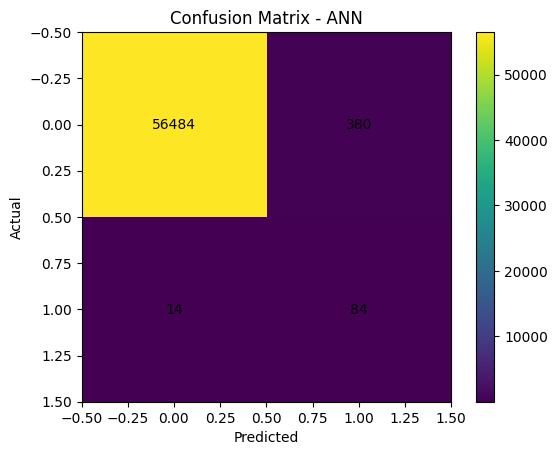

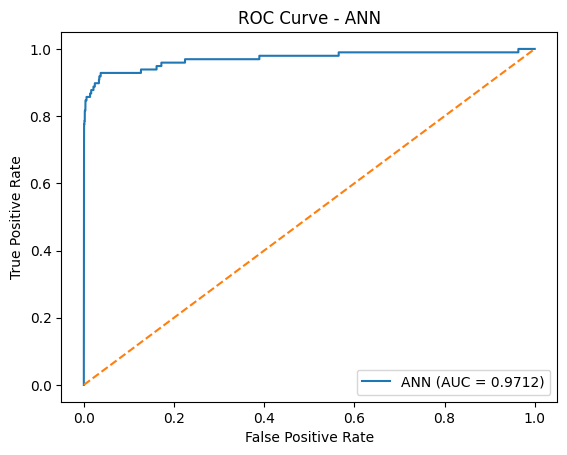

In [47]:
from sklearn.metrics import roc_auc_score, f1_score, accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt

# =========================
# Predictions
# =========================
y_pred_proba_ann = final_ann.predict(X_test_nn, verbose=0).flatten()
y_pred_ann = (y_pred_proba_ann > 0.5).astype(int)

# =========================
# Metrics
# =========================
roc_auc = roc_auc_score(y_test, y_pred_proba_ann)
f1 = f1_score(y_test, y_pred_ann)
acc = accuracy_score(y_test, y_pred_ann)

print("\n ANN Model Evaluation:")
print(f"ROC-AUC Score : {roc_auc:.4f}")
print(f"F1 Score      : {f1:.4f}")
print(f"Accuracy      : {acc:.4f}")

# =========================
# Classification Report
# =========================
print("\nClassification Report:")
print(classification_report(y_test, y_pred_ann))

# =========================
# Confusion Matrix
# =========================
cm = confusion_matrix(y_test, y_pred_ann)

plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix - ANN")
plt.xlabel("Predicted")
plt.ylabel("Actual")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.colorbar()
plt.show()

# =========================
# ROC Curve
# =========================
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(y_test, y_pred_proba_ann)

plt.figure()
plt.plot(fpr, tpr, label=f"ANN (AUC = {roc_auc:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - ANN")
plt.legend()

plt.show()

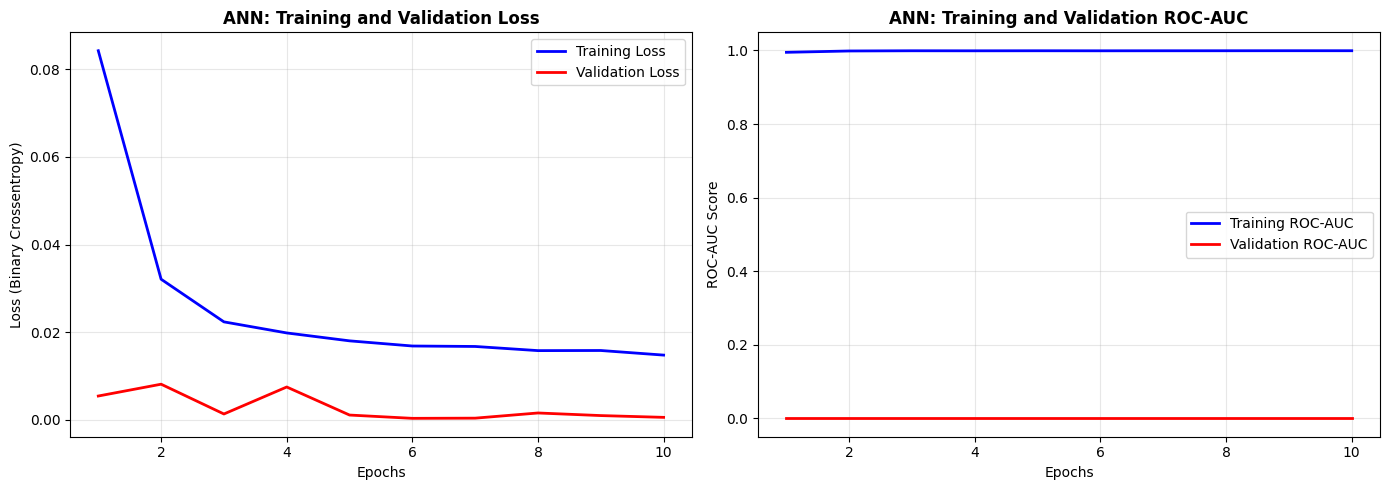

In [42]:
def plot_ann_performance(history):
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    auc = history.history['auc']
    val_auc = history.history['val_auc']
    
    epochs = range(1, len(loss) + 1)
    
    plt.figure(figsize=(14, 5))
    
    # Loss Plot
    plt.subplot(1, 2, 1)
    plt.plot(epochs, loss, 'b-', label='Training Loss', linewidth=2)
    plt.plot(epochs, val_loss, 'r-', label='Validation Loss', linewidth=2)
    plt.title('ANN: Training and Validation Loss', fontsize=12, fontweight='bold')
    plt.xlabel('Epochs')
    plt.ylabel('Loss (Binary Crossentropy)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # AUC Plot
    plt.subplot(1, 2, 2)
    plt.plot(epochs, auc, 'b-', label='Training ROC-AUC', linewidth=2)
    plt.plot(epochs, val_auc, 'r-', label='Validation ROC-AUC', linewidth=2)
    plt.title('ANN: Training and Validation ROC-AUC', fontsize=12, fontweight='bold')
    plt.xlabel('Epochs')
    plt.ylabel('ROC-AUC Score')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

plot_ann_performance(final_history)

In [ ]:
import joblib
joblib.dump(best_rf, "random_forest_model.pkl")

print("Model saved successfully!")

Model saved successfully!


,Model,ROC-AUC,F1 Score,Accuracy
0,Random Forest,0.963591,0.826531,0.999403
1,XGBoost,0.969458,0.694561,0.998718
2,ANN,0.971187,0.298932,0.993083


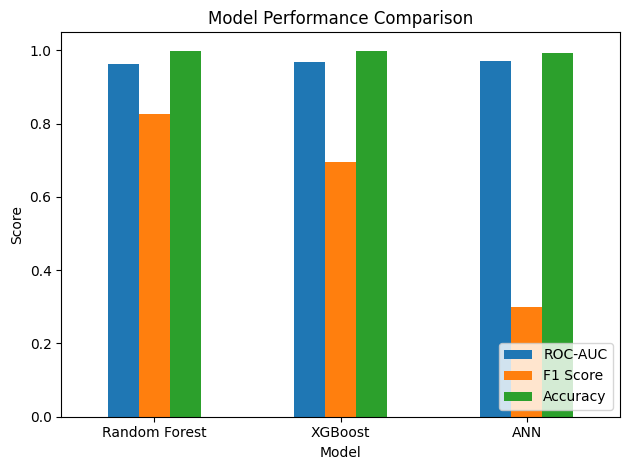

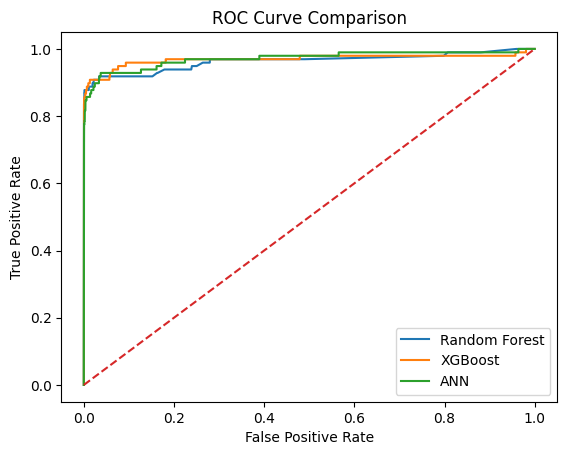

ANN


In [49]:
from sklearn.metrics import roc_auc_score, f1_score, accuracy_score, roc_curve
import pandas as pd
import matplotlib.pyplot as plt

results = []

y_pred_proba_rf = best_rf.predict_proba(X_test)[:, 1]
y_pred_rf = (y_pred_proba_rf > 0.5).astype(int)

results.append({
    "Model": "Random Forest",
    "ROC-AUC": roc_auc_score(y_test, y_pred_proba_rf),
    "F1 Score": f1_score(y_test, y_pred_rf),
    "Accuracy": accuracy_score(y_test, y_pred_rf)
})

y_pred_proba_xgb = best_xgb.predict_proba(X_test)[:, 1]
y_pred_xgb = (y_pred_proba_xgb > 0.5).astype(int)

results.append({
    "Model": "XGBoost",
    "ROC-AUC": roc_auc_score(y_test, y_pred_proba_xgb),
    "F1 Score": f1_score(y_test, y_pred_xgb),
    "Accuracy": accuracy_score(y_test, y_pred_xgb)
})

y_pred_proba_ann = final_ann.predict(X_test_nn, verbose=0).flatten()
y_pred_ann = (y_pred_proba_ann > 0.5).astype(int)

results.append({
    "Model": "ANN",
    "ROC-AUC": roc_auc_score(y_test, y_pred_proba_ann),
    "F1 Score": f1_score(y_test, y_pred_ann),
    "Accuracy": accuracy_score(y_test, y_pred_ann)
})

results_df = pd.DataFrame(results)
display(results_df)

results_df.set_index("Model").plot(kind="bar")

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

plt.figure()

fpr_rf, tpr_rf, _ = roc_curve(y_test, y_pred_proba_rf)
plt.plot(fpr_rf, tpr_rf, label="Random Forest")

fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_pred_proba_xgb)
plt.plot(fpr_xgb, tpr_xgb, label="XGBoost")

fpr_ann, tpr_ann, _ = roc_curve(y_test, y_pred_proba_ann)
plt.plot(fpr_ann, tpr_ann, label="ANN")

plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()

plt.show()

best_model_name = results_df.sort_values(by="ROC-AUC", ascending=False).iloc[0]["Model"]
print(best_model_name)